# The QMCPy Plot Projection Function for Discrete Distribution and True Measure

This notebook mirrors the QMCPy `plot_proj_function.ipynb` demo for projection plots of discrete distributions and true measures.

Original QMCPy demo: [`QMCPy/demos/plot_proj_function.ipynb`](../../QMCPy/demos/plot_proj_function.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/plot_proj_function.ipynb)

Parity note: this notebook keeps the same projection ideas from QMCPy, but `QMC.jl` does not currently ship a direct `plot_proj` helper. Instead, the shared comparisons are presented through compact `Plots.jl` figures when available, with numerical and ASCII summaries retained as headless-friendly fallback.


In [1]:
using QMC
import QMC: Uniform
using Statistics
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


### Here we set up the QMCPy environment enabling us to utilize this function:

The QMCPy notebook uses `plot_proj` together with matplotlib. Here we keep the same objects and pairwise-projection comparisons, but summarize them numerically and add compact `Plots.jl` figures so the notebook stays executable in both headless and interactive environments.


### Here we explain the parameters of the plot_proj function:

The examples below vary the discrete distribution or true measure, the ambient dimension `d`, and the sample count `n`. In the higher-dimensional section we inspect all 2D coordinate projections, which is the same structural information that QMCPy's plotting helper would visualize.


### The following examples show plotting of different Discrete Distribution Objects:

Start with two-dimensional projections of several discrete distributions.


=== 2D Point Set Statistics (n=128) ===



dim,mean,std,min,max,max gap,mean gap
1,0.4644,0.2706,0.0000,0.9875,0.0587,0.0078
2,0.4993,0.2764,0.0031,0.9869,0.0389,0.0077


  Correlation(d1,d2): 0.0027



dim,mean,std,min,max,max gap,mean gap
1,0.4967,0.2898,0.0006,0.9928,0.0078,0.0078
2,0.4992,0.2887,0.0019,0.9895,0.0123,0.0078


  Correlation(d1,d2): -0.0096



dim,mean,std,min,max,max gap,mean gap
1,0.5006,0.2898,0.0045,0.9967,0.0078,0.0078
2,0.4992,0.2898,0.0031,0.9953,0.0078,0.0078


  Correlation(d1,d2): -0.0002



dim,mean,std,min,max,max gap,mean gap
1,0.5029,0.2898,0.0068,0.9990,0.0078,0.0078
2,0.5027,0.2898,0.0066,0.9988,0.0078,0.0078


  Correlation(d1,d2): -0.0287



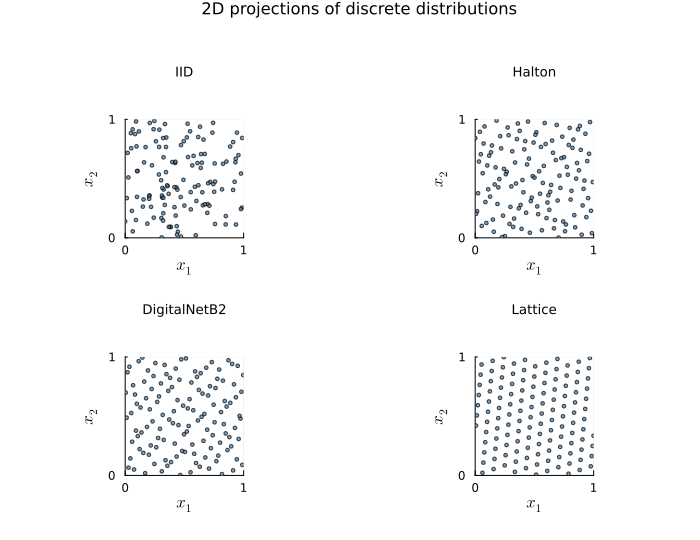

In [2]:
let n = 128
    println("=== 2D Point Set Statistics (n=$n) ===\n")
    point_sets = [
        ("IID", IIDStdUniform(2; seed=7)),
        ("Halton", Halton(2; seed=7)),
        ("DigitalNetB2", DigitalNetB2(2; seed=7)),
        ("Lattice", Lattice(2; seed=7)),
    ]
    saved_pts = Dict{String, Matrix{Float64}}()
    for (name, dd) in point_sets
        pts = gen_samples(dd, n)
        saved_pts[name] = pts
        rows = NamedTuple{(:dim, :mean, :std, :min, :max, :max_gap, :mean_gap)}[]
        for dim in 1:2
            col = pts[:, dim]
            s = sort(col)
            gaps = diff(s)
            push!(rows, (
                dim=dim,
                mean=mean(col),
                std=std(col),
                min=minimum(col),
                max=maximum(col),
                max_gap=maximum(gaps),
                mean_gap=mean(gaps)))
        end
        display(display_table(rows;
            caption=name,
            headers=["dim", "mean", "std", "min", "max", "max gap", "mean gap"],
            formatters=(
                mean=v -> @sprintf("%.4f", v),
                std=v -> @sprintf("%.4f", v),
                min=v -> @sprintf("%.4f", v),
                max=v -> @sprintf("%.4f", v),
                max_gap=v -> @sprintf("%.4f", v),
                mean_gap=v -> @sprintf("%.4f", v))))
        println("  Correlation(d1,d2): $(round(cor(pts[:,1], pts[:,2]), digits=4))\n")
    end
    if HAVE_PLOTS
        plots_list = Any[]
        for (name, _) in point_sets
            pts = saved_pts[name]
            local p = scatter(pts[:, 1], pts[:, 2];
                markersize=2, alpha=0.7, color=:steelblue, label=nothing,
                xlabel="\$x_1\$", ylabel="\$x_2\$", title=name,
                xlims=(0, 1), ylims=(0, 1), xticks=[0, 1], yticks=[0, 1],
                aspect_ratio=:equal, size=(240, 220))
            push!(plots_list, p)
        end
        display(plot(plots_list...; layout=(2, 2), size=(700, 540),
            plot_title="2D projections of discrete distributions",
            plot_titlevspan=0.12, top_margin=8Plots.mm, bottom_margin=5Plots.mm))
    end
end

For 4-dimensional sequences, inspect all pairwise 2-dimensional projections. This is a Julia extension inside the discrete-distribution section rather than a separate plotting API call.


=== Halton (4 D, 128 points) ===



dim 1,dim 2,dim 3,dim 4
1.0000,-0.0096,-0.0170,0.0073
-0.0096,1.0000,-0.0168,0.0125
-0.0170,-0.0168,1.0000,0.0596
0.0073,0.0125,0.0596,1.0000


dim,mean,max gap
1,0.4967,0.0078
2,0.4992,0.0123
3,0.4998,0.0080
4,0.5008,0.0117



=== DigitalNetB2 (4 D, 128 points) ===



dim 1,dim 2,dim 3,dim 4
1.0000,-0.0002,0.0005,0.0035
-0.0002,1.0000,0.0002,0.0002
0.0005,0.0002,1.0000,-0.0108
0.0035,0.0002,-0.0108,1.0000


dim,mean,max gap
1,0.5002,0.0078
2,0.5001,0.0078
3,0.4980,0.0078
4,0.5001,0.0078



=== Lattice (4 D, 128 points) ===



dim 1,dim 2,dim 3,dim 4
1.0000,-0.0687,-0.0071,0.0255
-0.0687,1.0000,-0.0255,0.0657
-0.0071,-0.0255,1.0000,-0.0778
0.0255,0.0657,-0.0778,1.0000


dim,mean,max gap
1,0.5028,0.0078
2,0.5030,0.0078
3,0.5018,0.0078
4,0.5023,0.0078


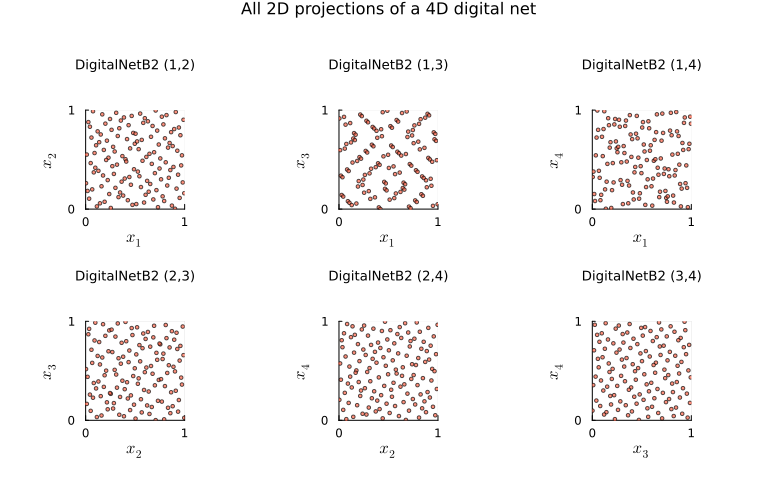

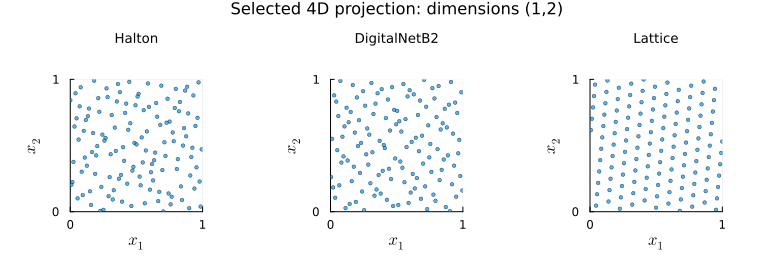

In [3]:
let n = 128, d = 4
    dd_all = [
        ("Halton", Halton(d; seed=7)),
        ("DigitalNetB2", DigitalNetB2(d; seed=7)),
        ("Lattice", Lattice(d; seed=7)),
    ]
    saved_pts = Dict{String, Matrix{Float64}}()
    for (name, dd) in dd_all
        pts = gen_samples(dd, n)
        saved_pts[name] = pts
        println("=== $name ($d D, $n points) ===\n")

        rows_cor = NamedTuple{(:d1, :d2, :d3, :d4)}[]
        for i in 1:d
            push!(rows_cor, (
                d1=cor(pts[:, i], pts[:, 1]),
                d2=cor(pts[:, i], pts[:, 2]),
                d3=cor(pts[:, i], pts[:, 3]),
                d4=cor(pts[:, i], pts[:, 4])))
        end
        display(display_table(rows_cor;
            caption="Pairwise correlations",
            headers=["dim 1", "dim 2", "dim 3", "dim 4"],
            formatters=(
                d1=v -> @sprintf("% .4f", v),
                d2=v -> @sprintf("% .4f", v),
                d3=v -> @sprintf("% .4f", v),
                d4=v -> @sprintf("% .4f", v))))

        rows_stats = NamedTuple{(:dim, :mean, :max_gap)}[]
        for dim in 1:d
            col = pts[:, dim]
            push!(rows_stats, (dim=dim, mean=mean(col), max_gap=maximum(diff(sort(col)))))
        end
        display(display_table(rows_stats;
            caption="Per-dimension statistics",
            headers=["dim", "mean", "max gap"],
            formatters=(
                mean=v -> @sprintf("%.4f", v),
                max_gap=v -> @sprintf("%.4f", v))))

        println()
    end

    if HAVE_PLOTS
        pts_dn = saved_pts["DigitalNetB2"]
        pair_plots = Any[]
        for (i, j) in [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
            local p = scatter(pts_dn[:, i], pts_dn[:, j];
                markersize=2, alpha=0.7, color=:tomato, label=nothing,
                xlabel="\$x_{$i}\$", ylabel="\$x_{$j}\$", title="DigitalNetB2 ($i,$j)",
                xlims=(0, 1), ylims=(0, 1), xticks=[0, 1], yticks=[0, 1],
                aspect_ratio=:equal, size=(220, 200))
            push!(pair_plots, p)
        end
        display(plot(pair_plots...; layout=(2, 3), size=(760, 480),
            plot_title="All 2D projections of a 4D digital net",
            plot_titlevspan=0.12, top_margin=8Plots.mm, bottom_margin=5Plots.mm))

        first_pair = Any[]
        for (name, _) in dd_all
            pts = saved_pts[name]
            local p = scatter(pts[:, 1], pts[:, 2];
                markersize=2, alpha=0.7, label=nothing,
                xlabel="\$x_1\$", ylabel="\$x_2\$", title=name,
                xlims=(0, 1), ylims=(0, 1), xticks=[0, 1], yticks=[0, 1],
                aspect_ratio=:equal, size=(240, 220))
            push!(first_pair, p)
        end
        display(plot(first_pair...; layout=(1, 3), size=(780, 260),
            plot_title="Selected 4D projection: dimensions (1,2)",
            plot_titlevspan=0.12, top_margin=8Plots.mm, bottom_margin=5Plots.mm))
    end
end

### The following examples show plotting of different True Measure Objects:

Apply true measures such as Gaussian transforms to the underlying point sets.


Gaussian(mean=[2,4], cov=[[9,4],[4,5]]) transform:



dim,mean,std,target mean,target std
1,1.86,2.91,2.00,3.00
2,3.85,2.11,4.00,2.24


Correlation: 0.572 (target: 0.596)


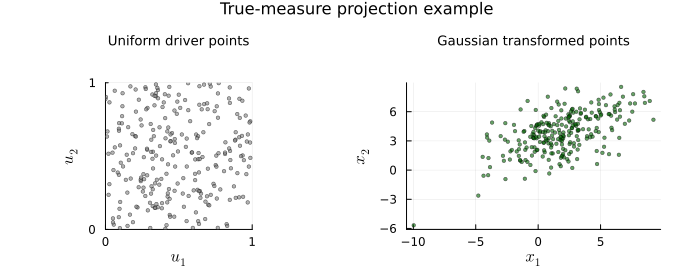

In [4]:
# Gaussian transform of IID points
dd = IIDStdUniform(2; seed=7)
tm = Gaussian(dd; mean=[2.0, 4.0], covariance=[9.0 4.0; 4.0 5.0])
n = 256
x_uniform = gen_samples(dd, n)
x_transformed = zeros(n, 2)
for i in 1:n
    x_transformed[i, :] = vec(transform(tm, x_uniform[i:i, :]))
end

println("Gaussian(mean=[2,4], cov=[[9,4],[4,5]]) transform:\n")
rows_gauss = NamedTuple{(:dim, :mean, :std, :target_mean, :target_std)}[]
push!(rows_gauss, (dim=1, mean=mean(x_transformed[:,1]), std=std(x_transformed[:,1]),
                   target_mean=2.0, target_std=3.0))
push!(rows_gauss, (dim=2, mean=mean(x_transformed[:,2]), std=std(x_transformed[:,2]),
                   target_mean=4.0, target_std=sqrt(5.0)))
display(display_table(rows_gauss;
    headers=["dim", "mean", "std", "target mean", "target std"],
    formatters=(
        mean=v -> @sprintf("%.2f", v),
        std=v -> @sprintf("%.2f", v),
        target_mean=v -> @sprintf("%.2f", v),
        target_std=v -> @sprintf("%.2f", v))))
println("Correlation: $(round(cor(x_transformed[:,1], x_transformed[:,2]), digits=3)) " *
        "(target: $(round(4/sqrt(9*5), digits=3)))")

if HAVE_PLOTS
    p1 = scatter(x_uniform[:, 1], x_uniform[:, 2];
        markersize=2, alpha=0.6, color=:gray, label=nothing,
        xlabel="\$u_1\$", ylabel="\$u_2\$", title="Uniform driver points",
        xlims=(0, 1), ylims=(0, 1), xticks=[0, 1], yticks=[0, 1],
        aspect_ratio=:equal, size=(280, 240))
    p2 = scatter(x_transformed[:, 1], x_transformed[:, 2];
        markersize=2, alpha=0.6, color=:darkgreen, label=nothing,
        xlabel="\$x_1\$", ylabel="\$x_2\$", title="Gaussian transformed points",
        size=(280, 240))
    display(plot(p1, p2; layout=(1, 2), size=(700, 280),
        plot_title="True-measure projection example", plot_titlevspan=0.12,
        top_margin=8Plots.mm, bottom_margin=5Plots.mm))
end

@assert size(x_transformed) == (n, 2)
@assert all(isfinite, x_transformed)
@assert isapprox(cov(x_transformed)[1, 2], 4.0; atol=1.0)

A simple ASCII projection view gives a text-only analogue of the same structure when a full plotting backend is unavailable. This is a Julia extension layered on top of the shared QMCPy examples.


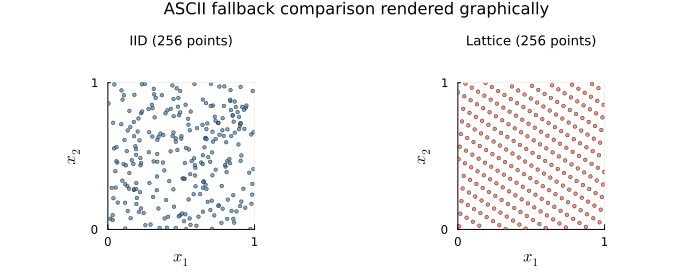

In [5]:
function ascii_scatter(x, y; width=60, height=20, title="")
    xmin, xmax = minimum(x), maximum(x)
    ymin, ymax = minimum(y), maximum(y)
    xr = xmax - xmin; yr = ymax - ymin
    if xr == 0; xr = 1.0; end
    if yr == 0; yr = 1.0; end
    grid = fill(' ', height, width)
    for i in eachindex(x)
        c = clamp(round(Int, (x[i] - xmin) / xr * (width - 1)) + 1, 1, width)
        r = clamp(height - round(Int, (y[i] - ymin) / yr * (height - 1)), 1, height)
        grid[r, c] = '·'
    end
    !isempty(title) && println(title)
    for r in 1:height
        println(String(grid[r, :]))
    end
    @printf("x: [%.2f, %.2f]  y: [%.2f, %.2f]
", xmin, xmax, ymin, ymax)
end

n = 256
dd_iid = IIDStdUniform(2; seed=42)
dd_lat = Lattice(2; seed=42)
x_iid = gen_samples(dd_iid, n)
x_lat = gen_samples(dd_lat, n)

if HAVE_PLOTS
    p1 = scatter(x_iid[:, 1], x_iid[:, 2];
        markersize=2, alpha=0.7, color=:steelblue, label=nothing,
        xlabel="\$x_1\$", ylabel="\$x_2\$", title="IID ($n points)",
        xlims=(0, 1), ylims=(0, 1), xticks=[0, 1], yticks=[0, 1],
        aspect_ratio=:equal, size=(280, 240))
    p2 = scatter(x_lat[:, 1], x_lat[:, 2];
        markersize=2, alpha=0.7, color=:tomato, label=nothing,
        xlabel="\$x_1\$", ylabel="\$x_2\$", title="Lattice ($n points)",
        xlims=(0, 1), ylims=(0, 1), xticks=[0, 1], yticks=[0, 1],
        aspect_ratio=:equal, size=(280, 240))
    display(plot(p1, p2; layout=(1, 2), size=(700, 280),
        plot_title="ASCII fallback comparison rendered graphically",
        plot_titlevspan=0.12, top_margin=8Plots.mm, bottom_margin=5Plots.mm))
else
    ascii_scatter(x_iid[:,1], x_iid[:,2]; title="
IID ($n points):")
    println()
    ascii_scatter(x_lat[:,1], x_lat[:,2]; title="Lattice ($n points):")
end
